In [80]:
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import astral
from astral import sun
from pandas.tseries.holiday import USFederalHolidayCalendar, get_calendar

In [81]:
scraped = pd.read_csv('ecocounter_bike_traffic_data.csv')
scraped["Date"] = scraped["Date"].apply(lambda x: datetime.datetime.strptime(x, '%Y-%m-%d'))
scraped = scraped.set_index("Date")

# Import and merge direct download count data

In [82]:
bike_direct = pd.read_csv('bike.csv')
bike_direct["DateTime"] = bike_direct["DateTime"].apply(lambda x: datetime.datetime.strptime(x, '%m/%d/%Y %H:%M'))
bike_direct = bike_direct.rename(columns = {'DateTime':'Date',
                                           '<tspan>IN (In)</tspan>':'In (Bike)',
                                           '<tspan>OUT (Out)</tspan>':'Out (Bike)'})
bike_direct["Total (Bike)"] = bike_direct["In (Bike)"] + bike_direct["Out (Bike)"]
bike_direct = bike_direct.set_index("Date")

In [83]:
scooter_direct = pd.read_csv('scooter.csv')
scooter_direct["DateTime"] = scooter_direct["DateTime"].apply(lambda x: datetime.datetime.strptime(x, '%m/%d/%Y %H:%M'))
scooter_direct = scooter_direct.rename(columns = {'DateTime':'Date',
                                           '<tspan>IN (In)</tspan>':'In (Scooter)',
                                           '<tspan>OUT (Out)</tspan>':'Out (Scooter)'})
scooter_direct["Total (Scooter)"] = scooter_direct["In (Scooter)"] + scooter_direct["Out (Scooter)"]
scooter_direct = scooter_direct.set_index("Date")

In [84]:
counts_direct = pd.merge(bike_direct,
                         scooter_direct,
                         how="outer",
                         left_index=True,
                         right_index=True
                        )
counts_direct["In"] = counts_direct["In (Bike)"] + counts_direct["In (Scooter)"]
counts_direct["Out"] = counts_direct["Out (Bike)"] + counts_direct["Out (Scooter)"]
counts_direct["Total"] = counts_direct["Total (Bike)"] + counts_direct["Total (Scooter)"]

Our scraped counts for both bike and scooter match the direct download data, so that's good

In [85]:
pd.merge(scraped, counts_direct, how="left", left_index=True, right_index=True)

,Count,In (Bike),Out (Bike),Total (Bike),In (Scooter),Out (Scooter),Total (Scooter),In,Out,Total
Date,,,,,,,,,,
2024-01-01,307,127,111,238,38,31,69,165,142,307
2024-01-02,360,128,158,286,25,49,74,153,207,360
2024-01-03,475,196,207,403,33,39,72,229,246,475
2024-01-04,580,232,244,476,56,48,104,288,292,580
2024-01-05,646,260,292,552,53,41,94,313,333,646
...,...,...,...,...,...,...,...,...,...,...
2025-12-27,231,66,93,159,31,41,72,97,134,231
2025-12-28,221,69,98,167,23,31,54,92,129,221
2025-12-29,295,88,140,228,26,41,67,114,181,295


### Merging day of week

In [86]:
counts_direct["Day of Week"] = counts_direct.index.day_name()

### Merging days of instruction and days of finals

In [87]:
finalsDates = pd.read_pickle('finalsDates.pkl')
instructionDates = pd.read_pickle('instructionDates.pkl')

# Filter to dates included in the data
finals_mask = (finalsDates <= counts_direct.index.max()) & (finalsDates >= counts_direct.index.min())
instruction_mask = (instructionDates <= counts_direct.index.max()) & (instructionDates >= counts_direct.index.min())
finalsDates = finalsDates[finals_mask]
instructionDates = instructionDates[instruction_mask]

# Make new column for whether a day is within the school year, a finals day, or neither
counts_direct["Academic Day"] = "Non-academic"
counts_direct.loc[finalsDates, "Academic Day"] = "Finals"
counts_direct.loc[instructionDates, "Academic Day"] = "Instruction"

### Merging holidays

Specifically only using holidays on the UC Davis academic calendar

In [88]:
holidayDates = pd.read_pickle('holidayDates.pkl')

# Filter to dates included in the data
holiday_mask = (holidayDates <= counts_direct.index.max()) & (holidayDates >= counts_direct.index.min())
holidayDates = holidayDates[holiday_mask]

# Make a new column for whether a day is a school holiday or not
counts_direct["Holiday"] = [index in holidayDates for index in counts_direct.index]

### Merging hours of daylight

In [89]:
def find_hours_daylight(datetime):
    # Create observer object at Davis bike counter location
    observer = astral.Observer(latitude=38.544406,
                           longitude=-121.74263)
    timedelta = astral.sun.sunrise(observer, datetime) - astral.sun.sunset(observer, datetime)
    seconds = timedelta.total_seconds()
    hours = seconds / 3600
    return hours

hours_of_daylight = []
for index in counts_direct.index:
    hours_of_daylight.append(find_hours_daylight(index))
hours_of_daylight

counts_direct["Hours of daylight"] = hours_of_daylight

### Merging Temperature

In [90]:
temperature = pd.read_csv("temperature.csv")
temperature = temperature[["DATE", "PRCP", "TMAX", "TMIN"]]
temperature = temperature.rename(columns={'DATE': 'Date',
                                          'PRCP': 'Precipitation',
                                          'TMAX': 'Max temperature',
                                          'TMIN': 'Min temperature'
                                         })
temperature["Date"] = temperature["Date"].apply(lambda x: datetime.datetime.strptime(x, '%Y-%m-%d'))
temperature = temperature.set_index('Date')

merged_data_direct = pd.merge(counts_direct,
                              temperature,
                              how='inner',
                              left_index=True,
                              right_index=True
                             )

### Resampling dataset to weekly counts

Counts were resampled using summation. Other columns had different aggregation functions:
- Academic Day: used the most common value (mode), e.g. if most days were finals days, that week was considered a finals week
- Holiday: if any day during that week was a holiday, that week was considered a holiday week
- Hours of daylight: used the mean value

In [91]:
counts_direct_weekly = counts_direct.resample("W", label='left').agg(
    In_Bike=('In (Bike)','sum'),
    Out_Bike=('Out (Bike)','sum'),
    Total_Bike=('Total (Bike)','sum'),
    In_Scooter=('In (Scooter)','sum'),
    Out_Scooter=('Out (Scooter)','sum'),
    Total_Scooter=('Total (Scooter)','sum'),
    In=('In','sum'),
    Out=('Out','sum'),
    Total=('Total','sum'),
    Academic_Day=('Academic Day',pd.Series.mode),
    Holiday=('Holiday','any'),
    Hours_of_daylight=('Hours of daylight','mean')
)

counts_direct_weekly = counts_direct_weekly.rename(columns={
    'In_Bike':'In (Bike)',
    'Out_Bike':'Out (Bike)',
    'Total_Bike':'Total (Bike)',
    'In_Scooter':'In (Scooter)',
    'Out_Scooter':'Out (Scooter)',
    'Total_Scooter':'Total (Scooter)',
    'Academic_Day':'Academic Day (Mode)',
    'Holiday':'Holiday (Any)',
    'Hours_of_daylight':'Hours of daylight (Mean)',
})

In [92]:
temperature_weekly = temperature.resample("W", label="left").agg(
    Precipitation_sum=('Precipitation', 'sum'),
    Max_temperature_max=('Max temperature', 'max'),
    Max_temperature_mean=('Max temperature', 'mean'),
    Min_temperature_min=('Min temperature', 'min'),
    Min_temperature_mean=('Min temperature', 'mean')
)
temperature_weekly = temperature_weekly.rename(columns={
    'Precipitation_sum': 'Precipitation (sum)',
    'Max_temperature_max':'Max temperature (max)',
    'Max_temperature_mean':'Max temperature (mean)',
    'Min_temperature_min':'Min temperature (min)',
    'Min_temperature_mean':'Min temperature (mean)'
})

In [93]:
merged_data_direct_weekly = pd.merge(counts_direct_weekly,
                                     temperature_weekly,
                                     how='inner',
                                     left_index=True,
                                     right_index=True
                                    )

### Filter dataset to relevant dates
Filter down to dates in 2024 and 2025 for full years of data--do note that for our weekly data, the date listed is the first day of that week. The first week available is only 1/7/2024, and we could manually add the week of 12/31/2023 if we want? We also have the week of 12/28/2025 even though some of the later days of that week spills over into 2026.

In [94]:
dateMask = (merged_data_direct.index >= datetime.datetime(2024, 1, 1)) & (merged_data_direct.index <= datetime.datetime(2025, 12, 31))
dateMask_weekly = (merged_data_direct_weekly.index >= datetime.datetime(2024, 1, 1)) & (merged_data_direct_weekly.index <= datetime.datetime(2025, 12, 31))

merged_data_direct = merged_data_direct[dateMask]
merged_data_direct_weekly = merged_data_direct_weekly[dateMask_weekly]

In [95]:
display(merged_data_direct, merged_data_direct_weekly)

,In (Bike),Out (Bike),Total (Bike),In (Scooter),Out (Scooter),Total (Scooter),In,Out,Total,Day of Week,Academic Day,Holiday,Hours of daylight,Precipitation,Max temperature,Min temperature
Date,,,,,,,,,,,,,,,,
2024-01-01,127,111,238,38,31,69,165,142,307,Monday,Non-academic,True,14.489649,0.00,60.0,41.0
2024-01-02,128,158,286,25,49,74,153,207,360,Tuesday,Non-academic,False,14.478673,0.00,64.0,44.0
2024-01-03,196,207,403,33,39,72,229,246,475,Wednesday,Non-academic,False,14.466712,0.37,55.0,42.0
2024-01-04,232,244,476,56,48,104,288,292,580,Thursday,Non-academic,False,14.453779,0.01,61.0,36.0
2024-01-05,260,292,552,53,41,94,313,333,646,Friday,Non-academic,False,14.439885,0.00,63.0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,66,93,159,31,41,72,97,134,231,Saturday,Non-academic,False,14.526470,0.09,60.0,38.0
2025-12-28,69,98,167,23,31,54,92,129,221,Sunday,Non-academic,False,14.520021,0.00,54.0,38.0
2025-12-29,88,140,228,26,41,67,114,181,295,Monday,Non-academic,False,14.512548,0.00,56.0,34.0


,In (Bike),Out (Bike),Total (Bike),In (Scooter),Out (Scooter),Total (Scooter),In,Out,Total,Academic Day (Mode),Holiday (Any),Hours of daylight (Mean),Precipitation (sum),Max temperature (max),Max temperature (mean),Min temperature (min),Min temperature (mean)
Date,,,,,,,,,,,,,,,,,
2024-01-07,6139,5582,11721,1024,788,1812,7163,6370,13533,Instruction,False,14.335397,0.24,60.0,57.285714,36.0,38.571429
2024-01-14,4995,4667,9662,914,717,1631,5909,5384,11293,Instruction,True,14.177091,1.04,66.0,61.857143,38.0,41.285714
2024-01-21,5900,5502,11402,1061,832,1893,6961,6334,13295,Instruction,False,13.983069,1.13,69.0,64.000000,33.0,45.714286
2024-01-28,5365,4961,10326,1016,803,1819,6381,5764,12145,Instruction,False,13.759835,2.69,73.0,66.142857,43.0,46.714286
2024-02-04,5342,5036,10378,986,715,1701,6328,5751,12079,Instruction,False,13.513649,1.46,65.0,61.428571,30.0,37.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30,4497,4605,9102,1797,1424,3221,6294,6029,12323,Instruction,False,14.389602,0.00,58.0,50.833333,37.0,40.166667
2025-12-07,2888,2981,5869,1147,976,2123,4035,3957,7992,Finals,False,14.486671,0.02,47.0,45.857143,39.0,41.000000
2025-12-14,951,997,1948,337,362,699,1288,1359,2647,Non-academic,False,14.535702,0.28,68.0,55.000000,39.0,45.571429


# Visualization

<Axes: xlabel='Date'>

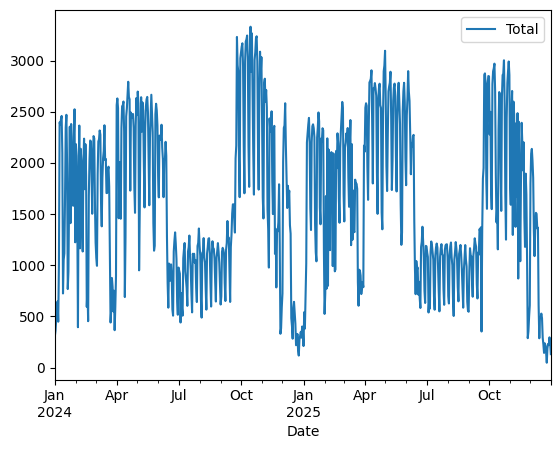

In [96]:
merged_data_direct[[
    # "In",
    # "Out",
    "Total"
]].plot()

<Axes: xlabel='Date'>

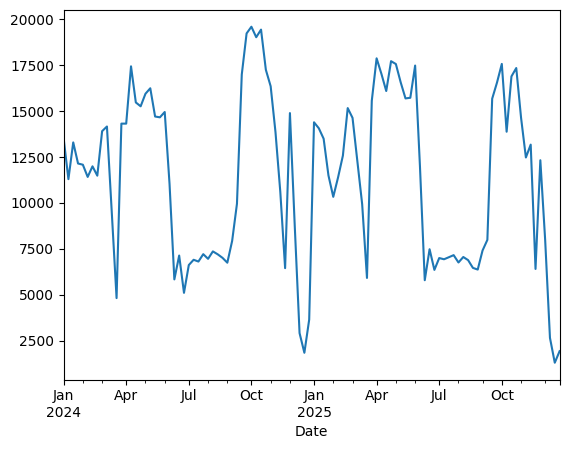

In [97]:
merged_data_direct_weekly["Total"].plot()

# Analysis

Assumptions
- Poisson Response: The response variable is a count per unit of time or space, described by a Poisson distribution.
- Independence: The observations must be independent of one another.
- Mean=Variance: By definition, the mean of a Poisson random variable must be equal to its variance.
- Linearity The log of the mean rate, log(λ), must be a linear function of x.

- https://bookdown.org/roback/bookdown-BeyondMLR/ch-poissonreg.html
- https://www.statsmodels.org/dev/generated/statsmodels.stats.stattools.durbin_watson.html
- https://stackoverflow.com/questions/28951982/using-weightings-in-a-poisson-model-using-statsmodels-module
- https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.NegativeBinomial.html
- https://timeseriesreasoning.com/contents/negative-binomial-regression-model/
- https://www.geeksforgeeks.org/data-science/create-a-correlation-matrix-using-python/

In [98]:
#%pip install statsmodels
#merged_data_direct.head()
merged_data_direct

,In (Bike),Out (Bike),Total (Bike),In (Scooter),Out (Scooter),Total (Scooter),In,Out,Total,Day of Week,Academic Day,Holiday,Hours of daylight,Precipitation,Max temperature,Min temperature
Date,,,,,,,,,,,,,,,,
2024-01-01,127,111,238,38,31,69,165,142,307,Monday,Non-academic,True,14.489649,0.00,60.0,41.0
2024-01-02,128,158,286,25,49,74,153,207,360,Tuesday,Non-academic,False,14.478673,0.00,64.0,44.0
2024-01-03,196,207,403,33,39,72,229,246,475,Wednesday,Non-academic,False,14.466712,0.37,55.0,42.0
2024-01-04,232,244,476,56,48,104,288,292,580,Thursday,Non-academic,False,14.453779,0.01,61.0,36.0
2024-01-05,260,292,552,53,41,94,313,333,646,Friday,Non-academic,False,14.439885,0.00,63.0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,66,93,159,31,41,72,97,134,231,Saturday,Non-academic,False,14.526470,0.09,60.0,38.0
2025-12-28,69,98,167,23,31,54,92,129,221,Sunday,Non-academic,False,14.520021,0.00,54.0,38.0
2025-12-29,88,140,228,26,41,67,114,181,295,Monday,Non-academic,False,14.512548,0.00,56.0,34.0


In [99]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf

## Poisson

In [100]:
merged_data_direct = merged_data_direct.reset_index()
poisson_model = smf.glm("Total ~ Q('Day of Week') + Q('Max temperature') + Q('Min temperature') + Q('Precipitation')", merged_data_direct, family=sm.families.Poisson())
results = poisson_model.fit(cov_type='HC0')
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Total   No. Observations:                  723
Model:                            GLM   Df Residuals:                      713
Model Family:                 Poisson   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.2687e+05
Date:                Mon, 09 Mar 2026   Deviance:                   2.4718e+05
Time:                        22:50:09   Pearson chi2:                 2.26e+05
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:                  HC0                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         7.7144      0.099     77.595      0.000       7.519       7.909
Q('Day of Week')[T.Monday]       -0.0144      0.061     -0.236      0.813      -0.134       0.105
Q('Day of Week')[T.Saturday]     -0.3182      0.063     -5.029      0.000      -0.442      -0.194
Q('Day of Week')[T.Sunday]       -0.4646      0.061     -7.657      0.000      -0.584      -0.346
Q('Day of Week')[T.Thursday]      0.0651      0.064      1.025      0.305      -0.059       0.190
Q('Day of Week')[T.Tuesday]       0.0714      0.058      1.230      0.219      -0.042       0.185
Q('Day of Week')[T.Wednesday]     0.0714      0.060      1.182      0.237      -0.047       0.190
Q('Max temperature')              0.0063      0.002      2.928      0.003       0.002       0.010
Q('Min temperature')             -0.0145      0.003     -4.497      0.000      -0.021      -0.008
Q('Precipitation')               -0.4711      0.142     -3.323      0.001      -0.749      -0.193
=================================================================================================
"""

In [101]:
#Assumption #1: Independence (use Durbin-Watson)
durbin_watson(results.resid_deviance, axis=0)

# Assumption #2: Mean=Variance (Equidispersion)
mean_count = merged_data_direct["Total"].mean()
variance_count = merged_data_direct["Total"].var()
print(f"Mean: {mean_count}, Variance: {variance_count}")


Mean: 1625.749658002736, Variance: 629296.8564211158


The equidispersion assumption for the Poisson model was violated, so we must refocus on robust forms of Poisson or other models.

## Negative Binomial

In [102]:
negative_binomial_model = smf.negativebinomial("Total ~ C(Q('Day of Week'), Treatment('Sunday')) + Q('Max temperature') + Q('Precipitation') + Q('Holiday') + Q('Academic Day') + Q('Hours of daylight')", merged_data_direct)
neg_bi_results = negative_binomial_model.fit()
neg_bi_results.summary()


nb_scooter = smf.negativebinomial("Q('Total (Scooter)') ~ C(Q('Day of Week'), Treatment('Sunday')) + Q('Max temperature') + Q('Precipitation') + Q('Holiday') + Q('Academic Day') + Q('Hours of daylight')", merged_data_direct)
nb_scooter_results = nb_scooter.fit()
nb_scooter_results.summary()

nb_bike = smf.negativebinomial("Q('Total (Bike)') ~ C(Q('Day of Week'), Treatment('Sunday')) + Q('Max temperature') + Q('Precipitation') + Q('Holiday') + Q('Academic Day') + Q('Hours of daylight')", merged_data_direct)
nb_bike_results = nb_bike.fit()
nb_bike_results.summary()

Optimization terminated successfully.
         Current function value: 7.452204
         Iterations: 29
         Function evaluations: 41
         Gradient evaluations: 41
Optimization terminated successfully.
         Current function value: 6.067335
         Iterations: 28
         Function evaluations: 38
         Gradient evaluations: 38
Optimization terminated successfully.
         Current function value: 7.244796
         Iterations: 25
         Function evaluations: 37
         Gradient evaluations: 37


<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      Q('Total (Bike)')   No. Observations:                  723
Model:               NegativeBinomial   Df Residuals:                      710
Method:                           MLE   Df Model:                           12
Date:                Mon, 09 Mar 2026   Pseudo R-squ.:                 0.08271
Time:                        22:50:09   Log-Likelihood:                -5238.0
converged:                       True   LL-Null:                       -5710.3
Covariance Type:            nonrobust   LLR p-value:                1.533e-194
=========================================================================================================================
                                                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------
Intercept                                                 6.3525      0.194     32.739      0.000       5.972       6.733
C(Q('Day of Week'), Treatment('Sunday'))[T.Friday]        0.4410      0.044     10.134      0.000       0.356       0.526
C(Q('Day of Week'), Treatment('Sunday'))[T.Monday]        0.4758      0.044     10.819      0.000       0.390       0.562
C(Q('Day of Week'), Treatment('Sunday'))[T.Saturday]      0.1491      0.043      3.444      0.001       0.064       0.234
C(Q('Day of Week'), Treatment('Sunday'))[T.Thursday]      0.4910      0.044     11.197      0.000       0.405       0.577
C(Q('Day of Week'), Treatment('Sunday'))[T.Tuesday]       0.5118      0.043     11.770      0.000       0.427       0.597
C(Q('Day of Week'), Treatment('Sunday'))[T.Wednesday]     0.4919      0.043     11.318      0.000       0.407       0.577
Q('Holiday')[T.True]                                     -0.9633      0.062    -15.599      0.000      -1.084      -0.842
Q('Academic Day')[T.Instruction]                          0.2542      0.056      4.568      0.000       0.145       0.363
Q('Academic Day')[T.Non-academic]                        -0.6924      0.057    -12.053      0.000      -0.805      -0.580
Q('Max temperature')                                      0.0080      0.001      6.826      0.000       0.006       0.010
Q('Precipitation')                                       -0.3700      0.057     -6.492      0.000      -0.482      -0.258
Q('Hours of daylight')                                   -0.0123      0.010     -1.251      0.211      -0.031       0.007
alpha                                                     0.0944      0.005     18.902      0.000       0.085       0.104
=========================================================================================================================
"""

We note that alpha is 0, and so we have overdispersion. Violation of equidispersion, Poisson should not be used.

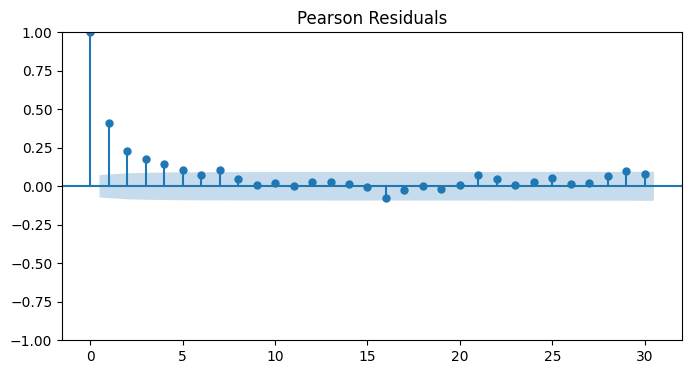

Optimization terminated successfully.
         Current function value: 7.452204
         Iterations: 29
         Function evaluations: 41
         Gradient evaluations: 41
                     NegativeBinomial Regression Results                      
Dep. Variable:                  Total   No. Observations:                  723
Model:               NegativeBinomial   Df Residuals:                      710
Method:                           MLE   Df Model:                           12
Date:                Mon, 09 Mar 2026   Pseudo R-squ.:                 0.08167
Time:                        22:50:09   Log-Likelihood:                -5387.9
converged:                       True   LL-Null:                       -5867.1
Covariance Type:            nonrobust   LLR p-value:                1.642e-197
                                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

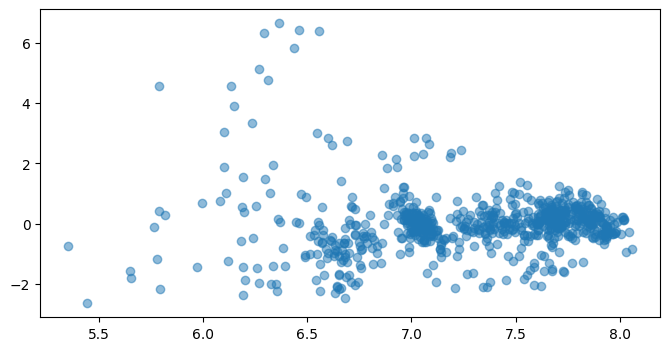

In [103]:
neg_bi_residuals = neg_bi_results.resid_pearson
neg_bi_residuals

#Assumption #1: Independence (use Durbin-Watson)
durbin_watson(neg_bi_residuals, axis=0)
## Also check for autocorrelation
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(neg_bi_residuals, lags=30, ax=ax)
plt.title("Pearson Residuals")
plt.show()

#Assumption #2: Linearity of Log-Link

neg_bi_results = negative_binomial_model.fit() 
fitted_values = neg_bi_results.fittedvalues

plt.figure(figsize=(8, 4))
plt.scatter(fitted_values, neg_bi_residuals, alpha=0.5)

# (Weak) Assumption #3: Overdispersion
print(neg_bi_results.summary())

## Coefficient Plot

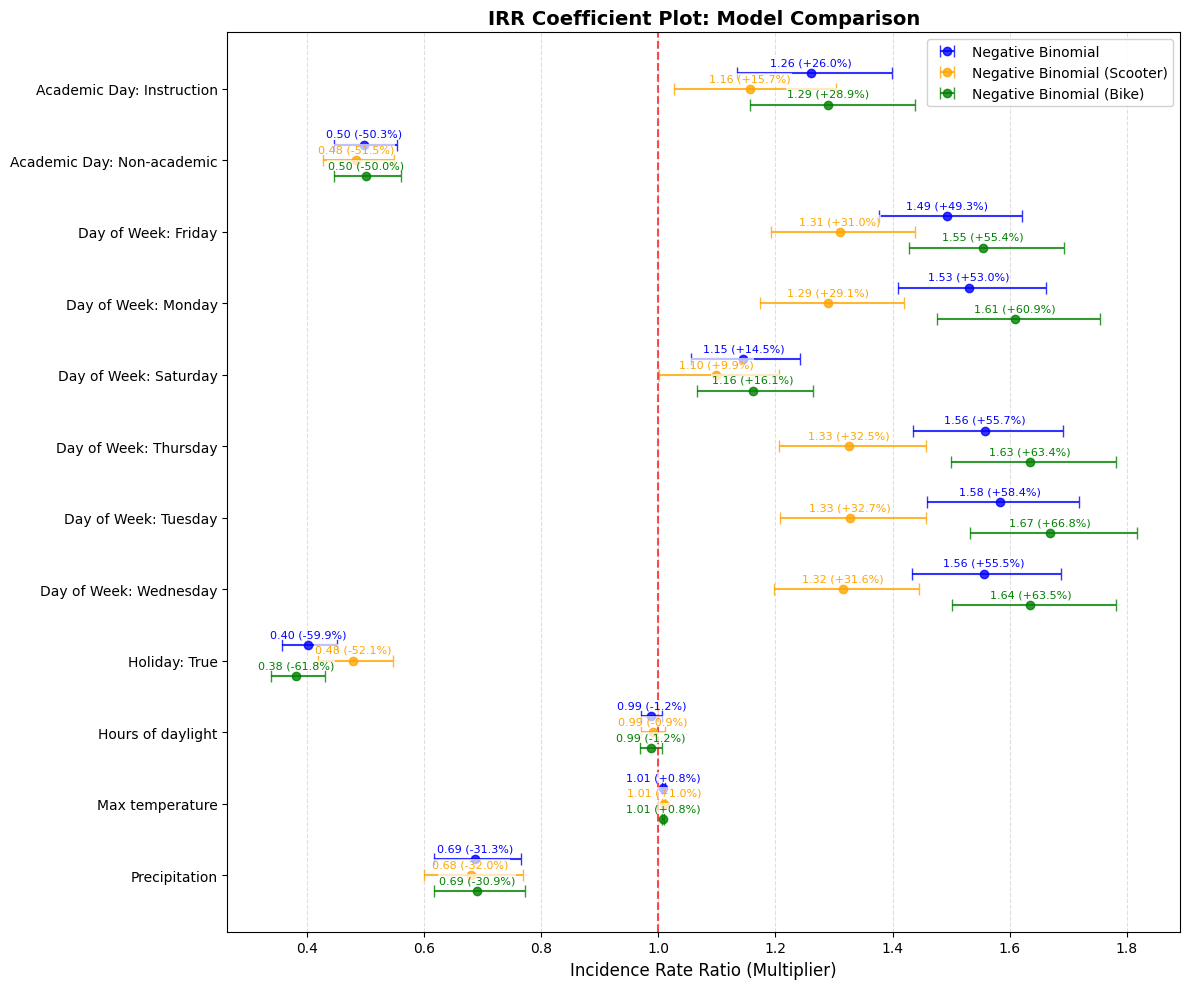

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

def clean_label(label):
    if '[T.' in label:
        var_match = re.search(r"Q\('(.*?)'\)", label)
        level_match = re.search(r"\[T\.(.*?)\]", label)
        if var_match and level_match:
            return f"{var_match.group(1)}: {level_match.group(1)}"
            
    label = label.replace("Q('", "").replace("')", "")
    return label

def prep_model_data(results):
    """Extracts, cleans, and formats coefficients for plotting as IRRs."""
    coefs = results.params
    conf_ints = results.conf_int()
    
    df = pd.DataFrame({
        'coef': coefs,
        'lower_ci': conf_ints[0],
        'upper_ci': conf_ints[1]
    })
    
    df = df.drop(['Intercept', 'alpha'], errors='ignore')
    df.index = df.index.map(clean_label)
    
   
    df['IRR'] = np.exp(df['coef'])
    df['IRR_lower'] = np.exp(df['lower_ci'])
    df['IRR_upper'] = np.exp(df['upper_ci'])
    
    
    df['err_lower_irr'] = df['IRR'] - df['IRR_lower']
    df['err_upper_irr'] = df['IRR_upper'] - df['IRR']
    
    return df.sort_index(ascending=False)

df1 = prep_model_data(neg_bi_results)
df2 = prep_model_data(nb_scooter_results) 
df3 = prep_model_data(nb_bike_results)


variables = df1.index.tolist()
y_pos = np.arange(len(variables))


fig, ax = plt.subplots(figsize=(12, 10))


offsets = [0.22, 0, -0.22] 
colors = ['blue', 'orange', 'green'] 
labels = ['Negative Binomial', 'Negative Binomial (Scooter)', 'Negative Binomial (Bike)']
dfs = [df1, df2, df3]


for i, df in enumerate(dfs):
    
    df = df.reindex(variables) 
    
    
    ax.errorbar(x=df['IRR'], 
                y=y_pos + offsets[i], 
                xerr=[df['err_lower_irr'], df['err_upper_irr']], 
                fmt='o', 
                color=colors[i], 
                label=labels[i],
                capsize=4,
                markersize=6,
                alpha=0.8)

    
    for j, (index, row) in enumerate(df.iterrows()):
        
        if pd.isna(row['IRR']):
            continue
            
        
        pct_change = (row['IRR'] - 1) * 100
        label_text = f"{row['IRR']:.2f} ({pct_change:+.1f}%)"
        
        
        ax.text(x=row['IRR'], 
                y=y_pos[j] + offsets[i] + 0.08, 
                s=label_text, 
                va='bottom', 
                ha='center', 
                fontsize=8, 
                color=colors[i], 
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.5))


ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(variables)


ax.set_xlabel('Incidence Rate Ratio (Multiplier)', fontsize=12)
ax.set_title('IRR Coefficient Plot: Model Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.legend(loc='best', framealpha=0.9)

plt.tight_layout()
plt.show()

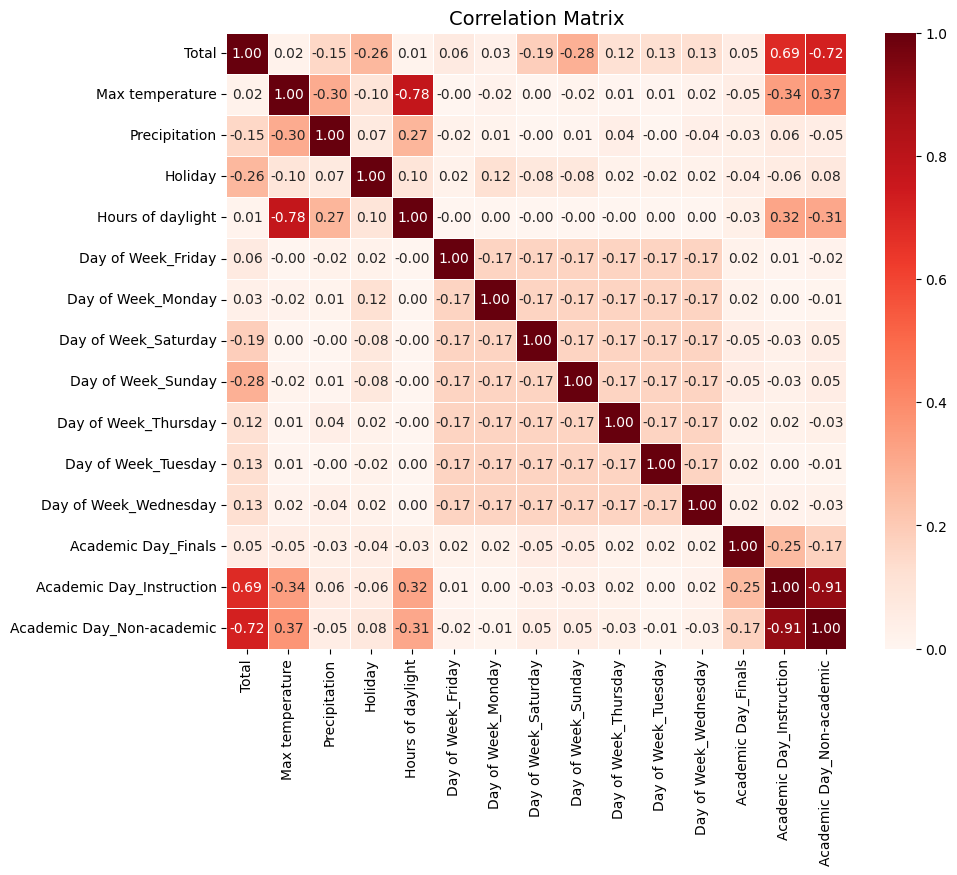

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

subset_merged = merged_data_direct[["Total", "Max temperature", "Precipitation", "Day of Week", "Holiday", "Academic Day", "Hours of daylight"]]
corr_merged = pd.get_dummies(subset_merged)
corr_matrix = corr_merged.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix.abs(), 
            annot=corr_matrix,
            cmap='Reds',
            fmt=".2f",
            vmin=0, vmax=1,
            linewidths=0.5)

plt.title("Correlation Matrix", fontsize=14)
plt.show()